In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
low_back_pain = pd.read_csv("../data/raw/Dataset_spine.csv")
low_back_pain.head()

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10,Col11,Col12,Class_att,Unnamed: 13
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0.744503,12.5661,14.5386,15.30468,-28.658501,43.5123,Abnormal,NaN
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal,NaN
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal,Prediction is done by using binary classificat...
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal,NaN
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal,NaN


In [3]:
low_back_pain.columns = ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius",
    "degree_spondylolisthesis", "pelvic_slope", "direct_tilt", "thoracic_slope", "cervical_tilt", "sacrum_angle",
    "scoliosis_slope", "class","notes"]

In [4]:
back_pain = low_back_pain.drop(["notes"],axis=1)
back_pain.head(10)

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,pelvic_slope,direct_tilt,thoracic_slope,cervical_tilt,sacrum_angle,scoliosis_slope,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0.744503,12.5661,14.5386,15.30468,-28.658501,43.5123,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,0.789993,29.3230,12.0036,10.40462,-1.512209,9.6548,Abnormal
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,0.198920,13.8514,10.7146,11.37832,-20.510434,25.9477,Abnormal
7,45.366754,10.755611,29.038349,34.611142,117.270067,-10.675871,0.131973,28.8165,7.7676,7.60961,-25.111459,26.3543,Abnormal
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,0.190408,22.7085,11.4234,10.59188,-20.020075,40.0276,Abnormal
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,0.367700,26.2011,8.7380,14.91416,-1.702097,21.4320,Abnormal


In [5]:
X = back_pain.drop(["class"], axis=1)
y = back_pain["class"]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=0, train_size=0.8, test_size=0.2, stratify=y)

In [6]:
numerical_columns = [col for col in X.columns if X[col].dtype in ['int64','float64']]
category_columns = [col for col in back_pain.columns if back_pain[col].dtype == "object" and back_pain[col].nunique() < 10]

In [7]:
numerical_transformer_xgb = SimpleImputer(strategy="mean")
numerical_transformer_log_r = Pipeline(steps=[('imputer', SimpleImputer(strategy="mean")), ('scaler', StandardScaler())])
preprocessor_xgb = ColumnTransformer(transformers=[('missing', numerical_transformer_xgb, numerical_columns),])
preprocessor_log_r = ColumnTransformer(transformers=[('missing', numerical_transformer_log_r, numerical_columns)])

In [8]:
param_grid_xgb = {'evaluation_model__n_estimators': [100, 200, 400],
                  'evaluation_model__learning_rate': [.01, 0.05, .1],
                  'evaluation_model__max_depth': [2, 3, 5],
                  'evaluation_model__min_child_weight': [1, 3, 5]}

pipeline_xgb = Pipeline(steps=[("preprocessing", preprocessor_xgb), ("evaluation_model", XGBClassifier(random_state=0))])
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
    )

grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="accuracy"
)

grid_search_xgb.fit(X_train, y_train)

best_xgb_model = grid_search_xgb.best_estimator_
print(grid_search_xgb.best_params_)
print(grid_search_xgb.best_score_)


{'evaluation_model__learning_rate': 0.05, 'evaluation_model__max_depth': 3, 'evaluation_model__min_child_weight': 1, 'evaluation_model__n_estimators': 100}
0.8385306122448981


In [9]:
param_grid_lr = {'evaluation_model__C':[0.01, 0.1, 1, 10, 100]}
pipeline_lr = Pipeline(steps=[("preprocessing", preprocessor_log_r),("evaluation_model", LogisticRegression(random_state=0, max_iter=1000))])
grid_search_lr = GridSearchCV( 
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="accuracy"

)

grid_search_lr.fit(X_train, y_train)
best_lr_model = grid_search_lr.best_estimator_
print(grid_search_lr.best_params_)
print(grid_search_lr.best_score_)

{'evaluation_model__C': 10}
0.8426122448979593


In [10]:
best_xgb_model_prediction = best_xgb_model.predict(X_test)
best_xgb_model_probabilities = best_xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, best_xgb_model_probabilities)

test_accuracy = accuracy_score(y_test, best_xgb_model_prediction)

print(f"Test Accuracy: {test_accuracy:.4f}")

print(classification_report(y_test, best_xgb_model_prediction))
print(confusion_matrix(y_test, best_xgb_model_prediction))
print(xgb_auc)


Test Accuracy: 0.8065
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        42
           1       0.72      0.65      0.68        20

    accuracy                           0.81        62
   macro avg       0.78      0.77      0.77        62
weighted avg       0.80      0.81      0.80        62

[[37  5]
 [ 7 13]]
0.9202380952380953


In [11]:
best_lr_predictions = best_lr_model.predict(X_test)
best_lr_probabilities = best_lr_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, best_lr_probabilities)

print(f"Accuracy: {accuracy_score(y_test, best_lr_predictions):.4f}")

print(classification_report(y_test, best_lr_predictions))

print(confusion_matrix(y_test, best_lr_predictions))

print(lr_auc)

Accuracy: 0.8387
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        42
           1       0.75      0.75      0.75        20

    accuracy                           0.84        62
   macro avg       0.82      0.82      0.82        62
weighted avg       0.84      0.84      0.84        62

[[37  5]
 [ 5 15]]
0.9392857142857143


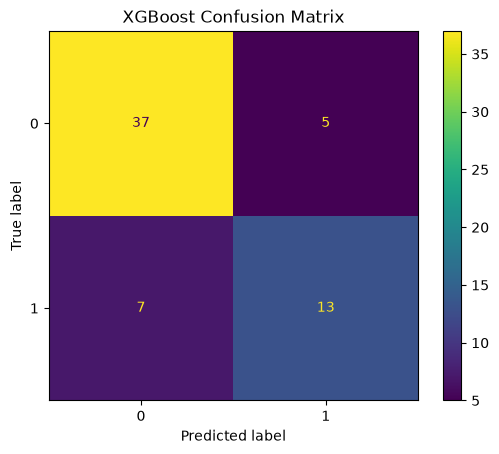

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_xgb_model_prediction
)

plt.title("XGBoost Confusion Matrix")
plt.show()

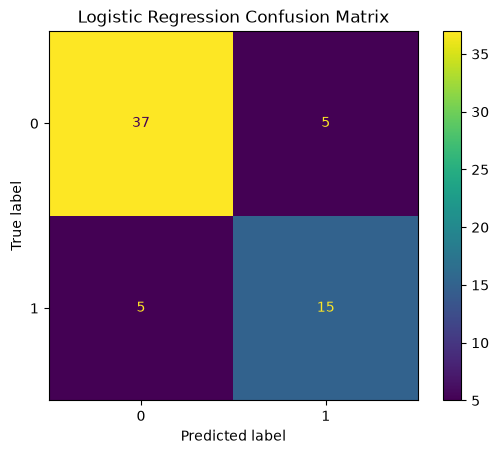

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, best_lr_predictions)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

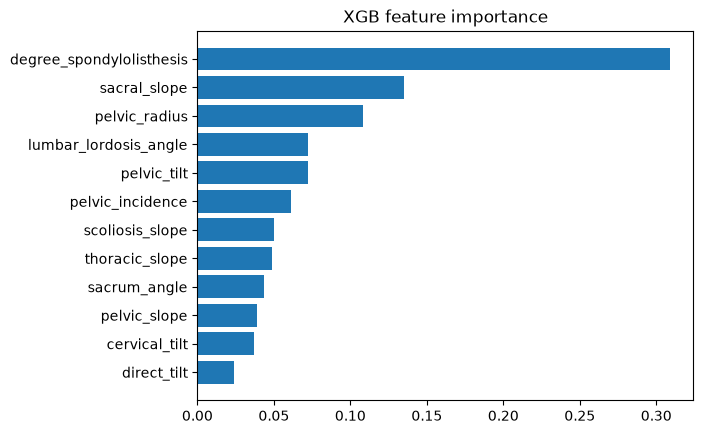

In [14]:
xgb_importances = best_xgb_model.named_steps["evaluation_model"].feature_importances_
sorted_idx = xgb_importances.argsort()
plt.barh(X_train.columns[sorted_idx], xgb_importances[sorted_idx])
plt.title("XGB feature importance")
plt.show()

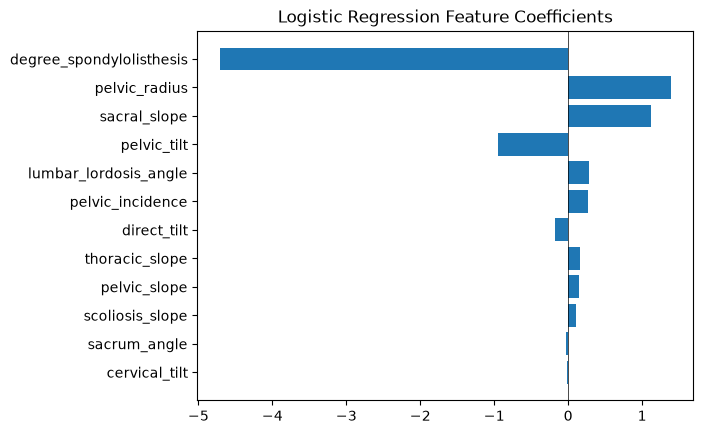

In [25]:
lr_coefficients = best_lr_model.named_steps["evaluation_model"].coef_[0]
sorted_idx_lr = abs(lr_coefficients).argsort()
plt.barh(X_train.columns[sorted_idx_lr],lr_coefficients[sorted_idx_lr])
plt.axvline(0, color="black", linewidth=.5)
plt.title("Logistic Regression Feature Coefficients")
plt.show()
